# Matheus Gabriel Alves da Silva
**RGM:** 11241100109

**Disciplina:** Inteligência Artificial  
**Curso:** Engenharia de Software  
**Turma:** 6B — Noite  
**Orientadores:** Prof. Higor Barreto

# SVM para Regressão: Previsão de Preços de Imóveis

Neste trabalho eu vou usar o **SVR** (a versão do SVM para prever números) para prever o **preço de imóveis**. A meta do professor é conseguir **R² maior que 0,65 no conjunto de teste**.

O que eu vou fazer, em ordem:
1. Conhecer o banco de dados e olhar os gráficos
2. Achar e tratar os valores ausentes e os outliers
3. Treinar um primeiro SVR e ir melhorando
4. Comparar tudo em tabelas e avaliar o resultado final

**Banco de dados:** Housing (Kaggle). Cada linha é um **distrito** da Califórnia, e o preço que vamos prever é o valor mediano das casas daquele distrito.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kathuman/housing/housing.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import time, warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("/kaggle/input/datasets/kathuman/housing/housing.csv")


# 2. Etapa 1: Conhecendo o banco de dados
## 2.1 Dimensões

In [5]:
print("Dimensões:", df.shape)
print("Duplicados:", df.duplicated().sum())
df.head()

Dimensões: (20640, 10)
Duplicados: 0


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2.2 Tipos de dados

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


- **float:** 9 colunas (longitude, latitude, idade das casas, total de cômodos, total de quartos, população, domicílios, renda mediana e o preço).
- **object (texto):** só `ocean_proximity`, que diz a distância do oceano. Como o SVR só entende números, eu vou ter que transformar essa coluna mais para frente.
- Não tem nenhuma coluna `int`.

## 2.3 Estatísticas descritivas


In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


**O que eu percebi:**

**Maior dispersão:** `total_rooms`, `population`, `total_bedrooms` e `households`. O desvio padrão é quase igual à média, então esses valores variam muito de um distrito para outro. `longitude` e `latitude` quase não variam.

**Valores muito altos:** `population` (máximo 35.682, mediana 1.166), `total_rooms` (máximo 39.320, mediana 2.127), `households` e `total_bedrooms`. Em todas, a média é maior que a mediana, ou seja, poucos distritos muito grandes puxam os valores para cima.

**Valores estranhos:**
- O preço tem máximo de **500.001**, que parece um teto da coleta e não um preço real. O mesmo acontece com `housing_median_age` (máximo 52) e `median_income` (máximo 15).
- Há distritos com 1 domicílio, 1 quarto de dormir ou 3 moradores, o que é pouco comum.
- `total_bedrooms` tem 207 valores ausentes.

**Relação com o preço:** a `median_income` (renda) parece ser a mais ligada ao preço. As outras eu vou confirmar na correlação mais abaixo.

**Para o modelo:** as variáveis têm escalas muito diferentes (renda perto de 4, população na casa dos milhares, preço na casa das centenas de milhares), então vou precisar **padronizar** os dados para o SVR.

## 2.4 Valores ausentes

In [8]:
print(df.isnull().sum())
print("\nColunas não numéricas:", list(df.select_dtypes(exclude='number').columns))

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Colunas não numéricas: ['ocean_proximity']


Só a coluna **`total_bedrooms`** tem valores ausentes: **207 linhas**, cerca de 1% do banco.

**Como eu vou tratar:** vou preencher com a **mediana** da coluna. Escolhi a mediana (e não a média) porque ela não é puxada pelos valores muito altos que vimos acima. Também prefiro preencher a apagar as linhas, porque o professor não deixa excluir dados à toa.

Um cuidado: a mediana vai ser calculada **só com os dados de treino** e depois aplicada no teste. Assim o teste continua "escondido" do modelo.

# 3. Etapa 2: Análise exploratória

In [9]:
ALVO = 'median_house_value'   # a coluna que eu quero prever (preço)

## Gráfico 1: Distribuição dos preços

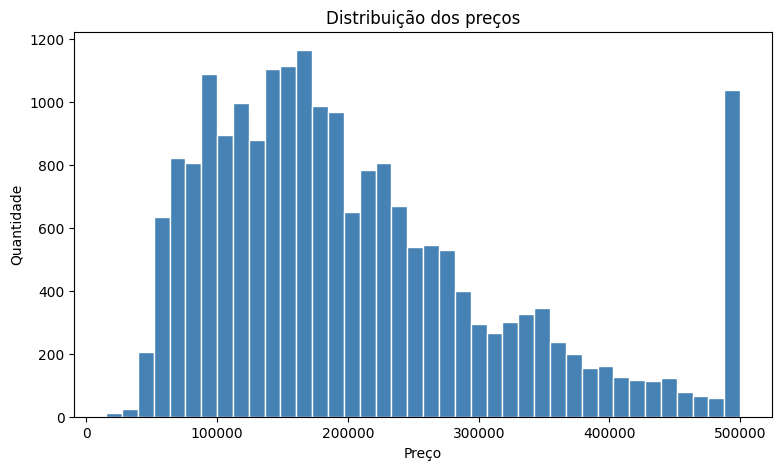

Quantos distritos têm o preço máximo (500001): 965


In [10]:
plt.figure(figsize=(9, 5))
plt.hist(df[ALVO], bins=40, color='steelblue', edgecolor='white')
plt.xlabel("Preço")
plt.ylabel("Quantidade")
plt.title("Distribuição dos preços")
plt.show()

print("Quantos distritos têm o preço máximo (500001):", (df[ALVO] == 500001).sum())

A maioria dos imóveis custa entre 100 mil e 300 mil, e tem poucos muito caros (cauda para a direita).

O mais interessante é a **barra isolada no final (500.001)**: são **965 distritos** com exatamente esse valor. Isso confirma que o preço foi **cortado em 500 mil** na hora de coletar o dado. Ou seja, casas que valem mais que isso aparecem como 500.001. Isso vai limitar o quanto qualquer modelo consegue acertar nas casas mais caras.

## Gráfico 2: Boxplots

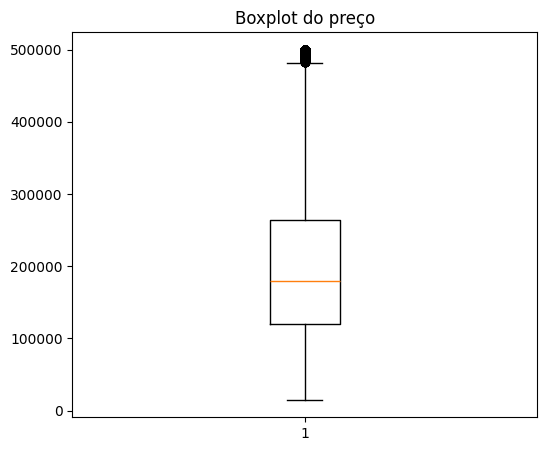

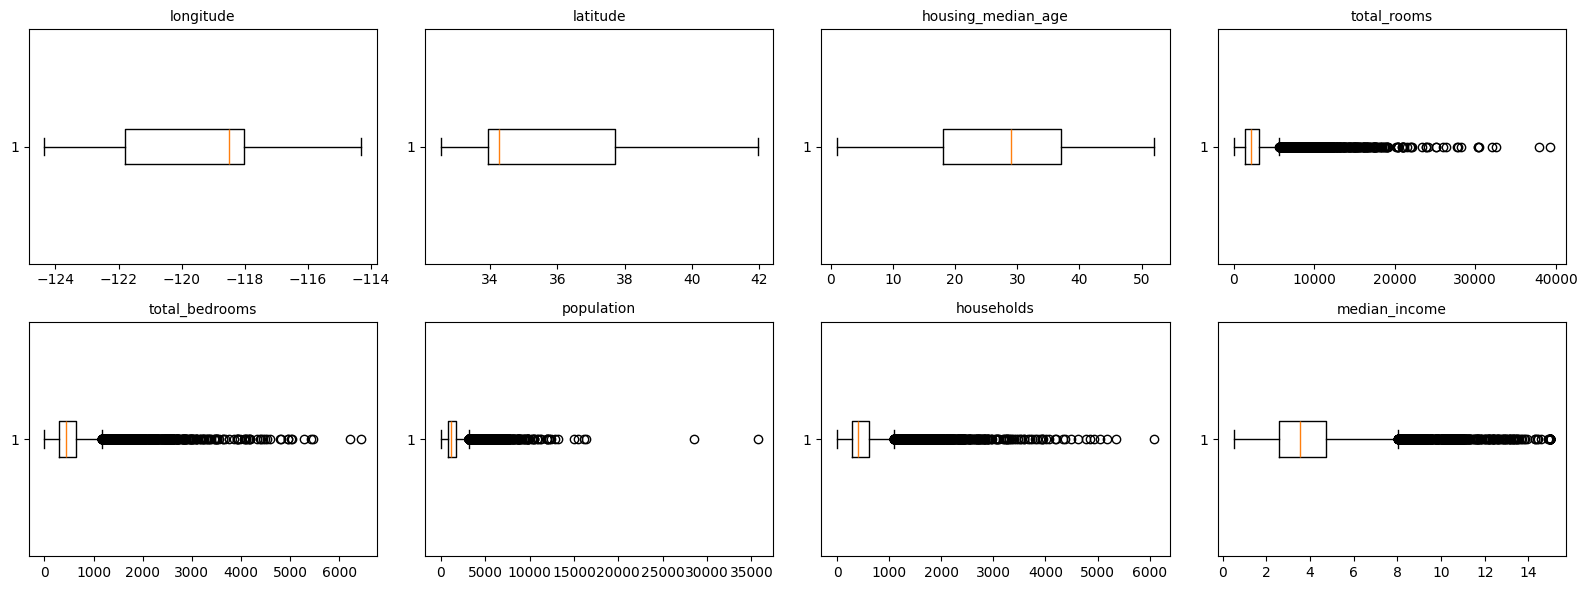

In [11]:
colunas_num = [c for c in df.select_dtypes(include='number').columns if c != ALVO]

plt.figure(figsize=(6, 5))
plt.boxplot(df[ALVO])
plt.title("Boxplot do preço")
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.ravel(), colunas_num):
    ax.boxplot(df[col].dropna(), vert=False)
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

No preço, os pontinhos lá em cima mostram os imóveis mais caros (muitos deles no teto de 500.001).

Nas outras variáveis, as que têm **muitos pontos fora da caixa** são `total_rooms`, `total_bedrooms`, `population` e `households`: tem distritos enormes bem acima do normal. `median_income` também tem alguns. Já `longitude`, `latitude` e `housing_median_age` não têm pontos fora, o que faz sentido, porque são localização e idade.

## Gráfico 3: Correlação

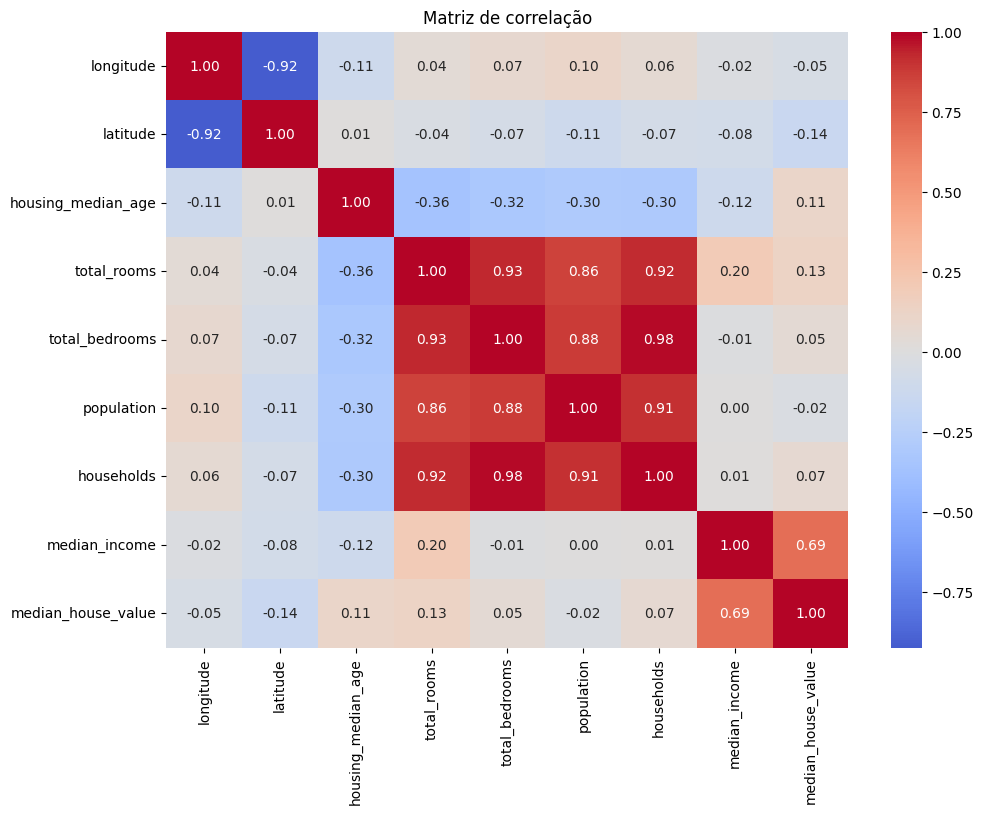

Correlação de cada variável com o preço:
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


In [12]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title("Matriz de correlação")
plt.show()

print("Correlação de cada variável com o preço:")
print(df.corr(numeric_only=True)[ALVO].drop(ALVO).sort_values(ascending=False).round(3))

**Mais ligada ao preço:** `median_income` (**0,69**). Quanto maior a renda do distrito, mais caro o imóvel. É a única com relação forte.

**Pouco relacionadas:** `total_rooms` (0,13), `housing_median_age` (0,11), `latitude` (-0,14) e as demais perto de zero (`households`, `total_bedrooms`, `population`, `longitude`).

**Variáveis redundantes (dizem quase a mesma coisa):** `total_bedrooms` e `households` (0,98), `total_rooms` com `total_bedrooms` (0,93) e com `households` (0,92), e `latitude` com `longitude` (-0,92). Faz sentido: todas medem o "tamanho" do distrito.

A localização também deve pesar (o litoral é mais caro que o interior), mas isso não aparece bem na correlação porque a relação não é uma linha reta. Vou ver isso na coluna `ocean_proximity`.

In [13]:
print(df.groupby('ocean_proximity')[ALVO].median().sort_values())

ocean_proximity
INLAND        108500.0
<1H OCEAN     214850.0
NEAR OCEAN    229450.0
NEAR BAY      233800.0
ISLAND        414700.0
Name: median_house_value, dtype: float64


Os distritos do **interior (INLAND)** têm preço mediano bem menor (cerca de 108 mil) que os perto do oceano ou da baía (cerca de 215 a 235 mil). Então `ocean_proximity` é uma variável importante e eu vou mantê-la.

# 4. Etapa 3: Identificando os outliers
Vou usar o método do **IQR**. A ideia: o que está muito abaixo de `Q1 - 1,5 × IQR` ou muito acima de `Q3 + 1,5 × IQR` é considerado outlier. Primeiro eu só **identifico**, sem remover nada.

In [14]:
linhas = []
for col in df.select_dtypes(include='number').columns:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    fora = (df[col] < lim_inf) | (df[col] > lim_sup)
    linhas.append({'variável': col, 'mín': df[col].min(), 'máx': df[col].max(),
                   'limite inferior': lim_inf, 'limite superior': lim_sup,
                   'qtd outliers': fora.sum(), '% outliers': round(fora.mean() * 100, 1)})

tabela_outliers = pd.DataFrame(linhas).set_index('variável')
tabela_outliers.round(1)

,mín,máx,limite inferior,limite superior,qtd outliers,% outliers
variável,,,,,,
longitude,-124.4,-114.3,-127.5,-112.3,0,0.0
latitude,32.5,42.0,28.3,43.4,0,0.0
housing_median_age,1.0,52.0,-10.5,65.5,0,0.0
total_rooms,2.0,39320.0,-1102.6,5698.4,1287,6.2
total_bedrooms,1.0,6445.0,-230.5,1173.5,1271,6.2
population,3.0,35682.0,-620.0,3132.0,1196,5.8
households,1.0,6082.0,-207.5,1092.5,1220,5.9
median_income,0.5,15.0,-0.7,8.0,681,3.3
median_house_value,14999.0,500001.0,-98087.5,482412.5,1071,5.2


**Método usado:** IQR (1,5 × IQR).

**O que encontrei:**
- Sem outliers: `longitude`, `latitude` e `housing_median_age`.
- Cerca de 6% de outliers em cada uma de `total_rooms` (6,2%), `total_bedrooms` (6,2%), `households` (5,9%) e `population` (5,8%).
- `median_income` tem 3,3% (681 distritos) e o preço tem 5,2% (1.071 distritos).

Os outliers do preço são em sua maioria os distritos do teto de 500.001.

# 5. Etapa 4: O que fazer com os outliers
**Minha decisão: limitar os valores (capping)**, ou seja, em vez de apagar o distrito, eu troco o valor extremo pelo limite do IQR.

**Por que eu escolhi isso:**
- Esses valores extremos parecem distritos **reais** (grandes), e não erros de cadastro. Apagar seria jogar informação fora.
- O professor não deixa excluir muitos dados (aqui seria perto de 6% do banco só em cada coluna).
- Por outro lado, deixar como está atrapalha o SVR, que é sensível a valores muito fora do padrão.
- O capping resolve os dois: **mantém todas as linhas** e reduz o peso dos extremos.

**Cuidados para o resultado ser honesto:**
- Os limites são calculados **só com o treino**.
- O preço do **teste nunca é alterado**. Assim o R² é medido nos preços de verdade.

# 6. Preparando os dados
O SVR só aceita números, então eu transformo a coluna `ocean_proximity` em colunas de 0 e 1 (uma para cada região) com `get_dummies`.

Depois eu separo **80% para treino e 20% para teste**, com `random_state=42`, como o professor pediu. **Essa divisão é feita uma vez só** e usada em todos os testes, para a comparação ser justa.

In [15]:
df_enc = pd.get_dummies(df, columns=['ocean_proximity'], dtype=float)

train_df, test_df = train_test_split(df_enc, test_size=0.20, random_state=42)
print("Treino:", train_df.shape)
print("Teste:", test_df.shape)

Treino: (16512, 14)
Teste: (4128, 14)


Agora eu crio duas funções para não repetir código:
- `tratar()`: aplica o tratamento de ausentes e/ou de outliers (sempre com base no treino).
- `rodar()`: treina o SVR (com ou sem padronização) e devolve o R², o MAE e o RMSE **no teste**.

**Sobre a padronização:** eu padronizo as variáveis (X) e também o preço (y). Isso é necessário porque o SVR usa o `epsilon` na mesma unidade do preço, e com preços na casa de centenas de milhares o valor padrão não funcionaria. Depois eu converto as previsões de volta para reais, então **as métricas são em preço de verdade**. O `fit` do padronizador é feito só no treino.

In [16]:
colunas_continuas = [c for c in df_enc.columns if c != ALVO and df_enc[c].nunique() > 2]  # ignora as colunas 0/1

def tratar(ausentes=False, outliers=False):
    tr, te = train_df.copy(), test_df.copy()

    if ausentes:
        medianas = tr.median()            # mediana calculada só no treino
        tr = tr.fillna(medianas)
        te = te.fillna(medianas)
    else:
        tr, te = tr.dropna(), te.dropna()  # sem tratamento: o SVR não aceita vazio, então descarta a linha

    X_tr, y_tr = tr.drop(columns=ALVO), tr[ALVO]
    X_te, y_te = te.drop(columns=ALVO), te[ALVO]

    if outliers:
        for col in colunas_continuas:      # capping com os limites do IQR do treino
            q1, q3 = X_tr[col].quantile(0.25), X_tr[col].quantile(0.75)
            iqr = q3 - q1
            X_tr[col] = X_tr[col].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
            X_te[col] = X_te[col].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
        q1, q3 = y_tr.quantile(0.25), y_tr.quantile(0.75)   # preço: só no treino
        y_tr = y_tr.clip(q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1))

    return X_tr, X_te, y_tr, y_te


def rodar(X_tr, X_te, y_tr, y_te, padronizar, **params):
    if padronizar:
        esc_x = StandardScaler().fit(X_tr)
        esc_y = StandardScaler().fit(y_tr.values.reshape(-1, 1))
        A, B = esc_x.transform(X_tr), esc_x.transform(X_te)
        alvo = esc_y.transform(y_tr.values.reshape(-1, 1)).ravel()
    else:
        A, B, alvo = X_tr, X_te, y_tr

    t0 = time.time()
    modelo = SVR(cache_size=1000, **params).fit(A, alvo)
    pred = modelo.predict(B)
    if padronizar:
        pred = esc_y.inverse_transform(pred.reshape(-1, 1)).ravel()   # volta para preço real

    return {'R²': r2_score(y_te, pred),
            'MAE': mean_absolute_error(y_te, pred),
            'RMSE': np.sqrt(mean_squared_error(y_te, pred)),
            'tempo (s)': round(time.time() - t0)}, pred

# 7. Etapa 8 e 12: Primeiro SVR e comparação antes/depois do tratamento
Aqui eu uso sempre o mesmo SVR (kernel RBF, `C=1`, `epsilon=0.1`) e vou **somando um tratamento de cada vez**, para ver o que realmente ajuda:

| Modelo | O que foi feito |
|---|---|
| Baseline | Nada (as linhas com valor ausente são descartadas e não tem padronização) |
| Modelo 2 | + preenche os valores ausentes |
| Modelo 3 | + trata os outliers |
| Modelo 4 | + padronização |

In [17]:
etapas = [('Baseline', 'Nenhum', False, False, False),
          ('Modelo 2', 'Valores ausentes', True, False, False),
          ('Modelo 3', 'Outliers', True, True, False),
          ('Modelo 4', 'Padronização', True, True, True)]

resultado_comp = []
for nome, trat, aus, out, pad in etapas:
    X_tr, X_te, y_tr, y_te = tratar(aus, out)
    m, _ = rodar(X_tr, X_te, y_tr, y_te, pad, kernel='rbf', C=1, epsilon=0.1)
    resultado_comp.append({'Modelo': nome, 'Tratamento': trat, 'R²': round(m['R²'], 4),
                           'MAE': round(m['MAE']), 'RMSE': round(m['RMSE'])})
    print(nome, '-> R² =', round(m['R²'], 4))

Baseline -> R² = -0.0485
Modelo 2 -> R² = -0.0487
Modelo 3 -> R² = -0.0482
Modelo 4 -> R² = 0.7474


In [18]:
tab_comp = pd.DataFrame(resultado_comp)
tab_comp

,Modelo,Tratamento,R²,MAE,RMSE
0,Baseline,Nenhum,-0.0485,87413,117383
1,Modelo 2,Valores ausentes,-0.0487,87344,117229
2,Modelo 3,Outliers,-0.0482,87325,117197
3,Modelo 4,Padronização,0.7474,38127,57536


**O que eu observo:** o R² do baseline fica **perto de zero** (ou negativo), ou seja, o modelo não aprende quase nada. Tratar os valores ausentes e os outliers muda muito pouco enquanto os dados **não estão padronizados**. O grande salto vem quando eu **padronizo**, no Modelo 4.

**Por que a padronização pesa tanto:** o SVR calcula distâncias entre os pontos. Sem padronizar, variáveis com números grandes (população, cômodos) dominam as pequenas (renda, latitude), e o modelo ignora o que realmente importa.

(Obs.: o baseline tem algumas linhas a menos no teste, porque as linhas com valor ausente foram descartadas.)

# 8. Etapa 9: Testando kernels
O kernel é a "forma" que o SVR usa para separar/ajustar os dados. Vou comparar `linear`, `rbf` e `poly`, já com os dados tratados e padronizados.

In [19]:
X_tr, X_te, y_tr, y_te = tratar(True, True)

res_kernel = []
for k in ['linear', 'rbf', 'poly']:
    m, _ = rodar(X_tr, X_te, y_tr, y_te, True, kernel=k)
    res_kernel.append({'Kernel': k, 'R²': round(m['R²'], 4), 'MAE': round(m['MAE']),
                       'RMSE': round(m['RMSE']), 'tempo (s)': m['tempo (s)']})
    print(k, '-> R² =', round(m['R²'], 4))

tab_kernel = pd.DataFrame(res_kernel)
tab_kernel

linear -> R² = 0.6156
rbf -> R² = 0.7474
poly -> R² = 0.6934


,Kernel,R²,MAE,RMSE,tempo (s)
0,linear,0.6156,50458,70969,37
1,rbf,0.7474,38127,57536,15
2,poly,0.6934,42005,63388,36


**O que eu observo:** o **RBF** foi o melhor (R² = 0,747), seguido do **poly** (0,693) e do **linear** (0,616). Os dois primeiros passam da meta de 0,65 e o linear fica abaixo. Isso faz sentido: a relação entre as características e o preço **não é uma linha reta** (a localização, por exemplo, muda o preço de forma irregular), e o RBF consegue acompanhar curvas.

# 9. Etapa 10: Melhorando com GridSearchCV
O `GridSearchCV` testa várias combinações de `C`, `epsilon`, `gamma` e `kernel` e escolhe a melhor usando validação cruzada (5 partes) com o R².

**Sobre a grade:** testei só o kernel `rbf` na busca, porque na seção anterior o `linear` e o `poly` já ficaram bem pior. O `linear` com `C` alto também é muito lento para treinar.

- `C`: o quanto o modelo tenta acertar os dados de treino (maior = mais ajustado).
- `epsilon`: uma margem de erro que o modelo aceita sem "punir".
- `gamma`: o alcance de cada ponto no kernel RBF.

**Um detalhe:** o SVR fica lento com muitas linhas. Por isso eu faço a **busca em uma amostra de 4.000 linhas do treino**, e depois **treino o melhor modelo com o treino completo**. O teste não é usado na busca.

In [20]:
X_tr, X_te, y_tr, y_te = tratar(True, True)

# padroniza o preço (com base no treino) para a busca
esc_y = StandardScaler().fit(y_tr.values.reshape(-1, 1))
y_esc = pd.Series(esc_y.transform(y_tr.values.reshape(-1, 1)).ravel(), index=y_tr.index)

amostra = X_tr.sample(4000, random_state=42)

parametros = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.2, 0.5],
    'svr__gamma': ['scale', 'auto'],
    'svr__kernel': ['rbf'],
}

t0 = time.time()
grid = GridSearchCV(Pipeline([('scaler', StandardScaler()), ('svr', SVR(cache_size=1000))]),
                    parametros, cv=5, scoring='r2', n_jobs=-1)
grid.fit(amostra, y_esc.loc[amostra.index])
print(f"Busca terminou em {time.time() - t0:.0f} segundos")

melhores = {k.replace('svr__', ''): v for k, v in grid.best_params_.items()}
print("Melhores parâmetros:", melhores)
print("Melhor R² na validação cruzada:", round(grid.best_score_, 4))

Busca terminou em 124 segundos
Melhores parâmetros: {'C': 10, 'epsilon': 0.2, 'gamma': 'auto', 'kernel': 'rbf'}
Melhor R² na validação cruzada: 0.7544


Agora eu treino o SVR com esses melhores parâmetros no **treino inteiro** e 

---

avalio no **teste**:

In [21]:
m_final, y_pred = rodar(X_tr, X_te, y_tr, y_te, True, **melhores)

print(f"R² final (teste): {m_final['R²']:.4f}")
print(f"MAE: {m_final['MAE']:,.0f}")
print(f"RMSE: {m_final['RMSE']:,.0f}")
print("\nMeta de R² > 0,65:", "ATINGIDA" if m_final['R²'] > 0.65 else "NÃO atingida")

R² final (teste): 0.7690
MAE: 36,862
RMSE: 55,018

Meta de R² > 0,65: ATINGIDA


# 10. Etapa 11: Experimentos
Mais três experimentos com valores de `C` e `epsilon` diferentes, mais o resultado do GridSearch.

In [22]:
exp = []

# Experimento 1: dados originais (é o mesmo Baseline da seção 7)
exp.append({'Experimento': 1, 'Tratamento': 'Dados originais', 'Kernel': 'RBF', 'C': 1, 'Epsilon': 0.1,
            'R²': tab_comp.loc[0, 'R²']})

# Experimento 2: tratamento de outliers (sem padronizar)
Xa, Xb, ya, yb = tratar(True, True)
m, _ = rodar(Xa, Xb, ya, yb, False, kernel='rbf', C=10, epsilon=0.1)
exp.append({'Experimento': 2, 'Tratamento': 'Tratamento de outliers', 'Kernel': 'RBF', 'C': 10, 'Epsilon': 0.1,
            'R²': round(m['R²'], 4)})

# Experimento 3: outliers + padronização
m, _ = rodar(Xa, Xb, ya, yb, True, kernel='rbf', C=100, epsilon=0.01)
exp.append({'Experimento': 3, 'Tratamento': 'Outliers + padronização', 'Kernel': 'RBF', 'C': 100, 'Epsilon': 0.01,
            'R²': round(m['R²'], 4)})

# Experimento 4: GridSearch (é o modelo final)
exp.append({'Experimento': 4, 'Tratamento': 'Dados tratados + GridSearch', 'Kernel': melhores['kernel'].upper(),
            'C': melhores['C'], 'Epsilon': melhores['epsilon'], 'R²': round(m_final['R²'], 4)})

tab_exp = pd.DataFrame(exp)
tab_exp

,Experimento,Tratamento,Kernel,C,Epsilon,R²
0,1,Dados originais,RBF,1,0.10,-0.0485
1,2,Tratamento de outliers,RBF,10,0.10,-0.0372
2,3,Outliers + padronização,RBF,100,0.01,0.7663
3,4,Dados tratados + GridSearch,RBF,10,0.20,0.7690


**O que eu observo:**
- Sem padronizar (experimentos 1 e 2), o R² continua perto de zero, não importa o valor de `C`. Ou seja, **ajustar parâmetros não resolve** se os dados não estão na mesma escala.
- Com padronização (experimento 3, `C = 100` e `epsilon = 0,01`), o R² sobe para 0,766, um pouco acima do SVR padrão (0,747).
- O GridSearch (experimento 4) achou uma combinação ainda melhor (0,769), com `C = 10` e `epsilon = 0,2`. A diferença entre os experimentos 3 e 4 é pequena, então a maior parte do ganho já vinha da padronização.

# 11. Etapa 12 (de novo): Tabela final antes e depois
Juntando o modelo final com a tabela da seção 7:

In [23]:
final = pd.DataFrame([{'Modelo': 'Modelo final', 'Tratamento': 'Otimização (GridSearch)',
                       'R²': round(m_final['R²'], 4), 'MAE': round(m_final['MAE']), 'RMSE': round(m_final['RMSE'])}])
tab_antes_depois = pd.concat([tab_comp, final], ignore_index=True)
tab_antes_depois

,Modelo,Tratamento,R²,MAE,RMSE
0,Baseline,Nenhum,-0.0485,87413,117383
1,Modelo 2,Valores ausentes,-0.0487,87344,117229
2,Modelo 3,Outliers,-0.0482,87325,117197
3,Modelo 4,Padronização,0.7474,38127,57536
4,Modelo final,Otimização (GridSearch),0.7690,36862,55018


# 12. Etapa 13 e 14: Avaliação final

In [24]:
avaliacao = pd.DataFrame({'Métrica': ['R²', 'MAE', 'RMSE'],
                          'Valor (teste)': [round(m_final['R²'], 4), round(m_final['MAE']), round(m_final['RMSE'])]})
avaliacao

,Métrica,Valor (teste)
0,R²,0.769
1,MAE,36862.000
2,RMSE,55018.000


- **R²:** quanto da variação dos preços o modelo consegue explicar (1 seria perfeito).
- **MAE:** o erro médio das previsões, em dólares.
- **RMSE:** parecido com o MAE, mas pune mais os erros grandes.

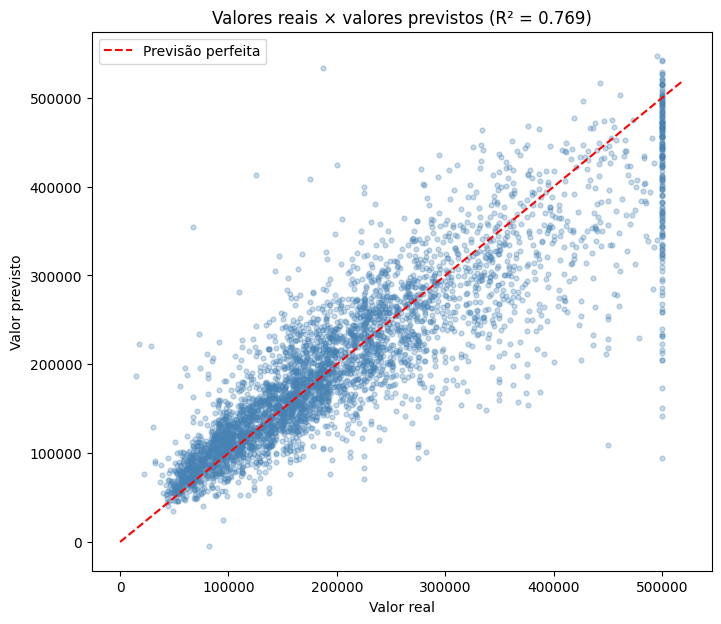

In [25]:
plt.figure(figsize=(8, 7))
plt.scatter(y_te, y_pred, alpha=0.3, s=12, color='steelblue')
limites = [0, 520000]
plt.plot(limites, limites, 'r--', label='Previsão perfeita')
plt.xlabel("Valor real")
plt.ylabel("Valor previsto")
plt.title(f"Valores reais × valores previstos (R² = {m_final['R²']:.3f})")
plt.legend()
plt.show()

**Como ler o gráfico:** quanto mais perto os pontos estão da linha vermelha, melhor a previsão. Os pontos seguem a diagonal, então o modelo acerta a tendência.

Dá para ver também uma **faixa vertical de pontos em 500.000**: são os distritos com o preço cortado no teto. Para esses o modelo erra mais (ele prevê valores abaixo do real), porque o dado já vem "cortado".

# 13. Conclusão

**O modelo atingiu R² > 0,65?**  
**Sim.** O modelo final chegou a **R² = 0,769 no conjunto de teste** (dados que ele nunca viu no treino). Isso quer dizer que ele explica cerca de 77% da variação dos preços. O erro médio (MAE) ficou em cerca de **36.900 dólares** e o RMSE em cerca de **55.000**.

**Qual tratamento teve maior impacto?**  
A **padronização**, de longe. Sem ela, o R² ficou negativo (-0,05), ou seja, o modelo era pior que simplesmente chutar a média. Com a padronização, foi para 0,747. Isso acontece porque o SVR calcula distâncias, e variáveis com números grandes (população, cômodos) dominavam as pequenas (renda, latitude).

**O tratamento dos outliers melhorou o resultado?**  
Quase nada. Sem padronização, o R² continuou em -0,05. Com padronização, o resultado com e sem o capping foi praticamente igual (cerca de 0,746 sem e 0,747 com). Eu mantive o capping porque não custa nada (não apaga nenhuma linha) e deixa o modelo mais seguro contra valores extremos, mas aqui ele não foi o fator decisivo.

**Qual kernel foi melhor?**  
O **RBF**, com R² de 0,747. O poly ficou com 0,693 e o linear com 0,616. Isso faz sentido: a relação entre as características e o preço não é uma linha reta, e o RBF acompanha melhor essas curvas.

**Quais hiperparâmetros foram usados no modelo final?**  
Kernel **RBF**, **C = 10**, **epsilon = 0,2** e **gamma = 'auto'**, escolhidos pelo GridSearchCV. Com os parâmetros padrão o R² era 0,747, e com os parâmetros escolhidos subiu para 0,769. Mesmo o experimento 3 (C = 100, epsilon = 0,01) ficou perto, com 0,766.

**Quais dificuldades eu encontrei?**
- O SVR é **lento** quando tem muitas linhas (20 mil). A busca do GridSearch com kernel linear e `C` alto demorava demais, então eu busquei só com o RBF e numa amostra de 4.000 linhas do treino.
- A **escala dos dados**, principalmente do preço. Foi preciso padronizar o preço também.
- O **teto de 500.001 no preço**: 965 distritos têm esse valor cortado, e o modelo erra mais nesses casos (dá para ver a faixa vertical no gráfico real × previsto).
- Decidir o que fazer com os outliers sem apagar dados.

**O modelo poderia ser melhorado? Como?**
- Fazer o GridSearch com o **treino completo** (não só uma amostra) e testar mais valores de `C`, `epsilon` e `gamma`.
- Usar o **logaritmo do preço**, que costuma ajudar quando há muitos imóveis baratos e poucos muito caros.
- Criar **novas características**, como cômodos por domicílio ou quartos por cômodo, que dizem mais que o total do distrito.
- Tirar variáveis **redundantes** (por exemplo `total_bedrooms`, que é quase igual a `households`).
- Comparar com outros modelos (como Random Forest) para ver o que o SVR deixa de aprender.
